# StreamWise
Multimodal workflow cost estimator.

In [1]:
import pandas as pd
import os

from dataclasses import replace

In [2]:
from data_loading import load_latency_data
from data_loading import load_power_data
from data_loading import load_adaptive_quality_data

from utils import find_most_cost_effective_provisioning
from utils import find_most_energy_efficient_provisioning
from utils import find_fastest_provisioning
from utils import find_cheapest_provisioning

from plot_utils import plot_ttff_vs_cost
from plot_utils import plot_adaptive_quality

In [3]:
from constants import DEFAULT_WORKFLOW_CONFIG

from provisioning import get_provisioning_results
from provisioning import get_provisioning_adaptive_results

from sim_types import ProvisioningResult
from sim_types import GPUType
from sim_types import QualityLevel
from sim_types import LatencyData
from sim_types import num_gpus_to_str

from policies import STREAMWISE_POLICY

In [4]:
data_dir = "data/"
results_dir = "results/"

In [5]:
os.makedirs(results_dir, exist_ok=True)

## Settings
Configuration for workflow and models.

In [6]:
# for a podcast 10 minute / 600 seconds video
workflow_config = DEFAULT_WORKFLOW_CONFIG

In [7]:
latency_data = load_latency_data(data_dir=data_dir)
power_data = load_power_data(data_dir=data_dir)

## StreamCast
Podcast generation.

In [8]:
provisioning_streamwise = get_provisioning_results(
    workflow=workflow_config,
    latency_data=latency_data,
    power_data=power_data,
    policy=STREAMWISE_POLICY,
    verbose=False,
)

streamwise policy:   0%|          | 0/4816 [00:00<?, ?it/s]

In [9]:
result_idx_cost_effective = find_most_cost_effective_provisioning(provisioning_streamwise)

latency = provisioning_streamwise.latencies[result_idx_cost_effective]
cost = provisioning_streamwise.costs[result_idx_cost_effective]
energy = provisioning_streamwise.energies[result_idx_cost_effective]
provision = provisioning_streamwise.actual_provision[result_idx_cost_effective]
models = provisioning_streamwise.model_provision[result_idx_cost_effective]
print(f"Most cost-effective solution with {latency:.1f} seconds, ${cost:.1f}, {energy:.1f} Ws: {num_gpus_to_str(provision)}")

print("Model allocations:")
for gpu_type, model_alloc in models.items():
    print(f"  {gpu_type.value}")
    for model, allocs in model_alloc.items():
        for alloc in allocs:
            num_gpus = alloc.get_num_gpus()
            print(f"    {num_gpus:4d}x{gpu_type.value} {model.value:10}: {alloc}")

Most cost-effective solution with 217.4 seconds, $42.8, 21658259.5 Ws: 508xA100+39xH100
Model allocations:
  A100
       8xA100 gemma     : devices= 8, replicas=1, work=0, time=8.57 secs, time_first=1.48 secs, energy=230.06 Wh, cost=$0.52
      16xA100 flux      : devices=16, replicas=1, work=0, time=0.95 secs, time_first=0.95 secs, energy=63.01 Wh, cost=$1.03
      18xA100 hf        : devices= 2, replicas=9, work=0, time=21.47 secs, time_first=2.03 secs, energy=80.81 Wh, cost=$1.16
      44xA100 hf        : devices= 1, replicas=44, work=0, time=21.27 secs, time_first=2.97 secs, energy=189.39 Wh, cost=$2.84
      31xA100 vae       : devices= 1, replicas=31, work=0, time=8.63 secs, time_first=1.98 secs, energy=124.55 Wh, cost=$2.00
     120xA100 ft        : devices=40, replicas=3, work=0, time=124.40 secs, time_first=19.64 secs, energy=1737.10 Wh, cost=$7.76
     104xA100 ft        : devices= 4, replicas=26, work=0, time=122.90 secs, time_first=58.10 secs, energy=1529.38 Wh, cost=$6.72


In [10]:
result_idx_energy_efficient = find_most_energy_efficient_provisioning(provisioning_streamwise)

latency = provisioning_streamwise.latencies[result_idx_energy_efficient]
cost = provisioning_streamwise.costs[result_idx_energy_efficient]
energy = provisioning_streamwise.energies[result_idx_energy_efficient]
provision = provisioning_streamwise.actual_provision[result_idx_energy_efficient]
models = provisioning_streamwise.model_provision[result_idx_energy_efficient]
print(f"Most energy-efficient solution with {latency:.1f} seconds, ${cost:.1f}, {energy:.1f} Ws: {num_gpus_to_str(provision)}")

print("Model allocations:")
for gpu_type, model_alloc in models.items():
    print(f"  {gpu_type.value}")
    for model, allocs in model_alloc.items():
        for alloc in allocs:
            num_gpus = alloc.get_num_gpus()
            print(f"    {num_gpus:4d}x{gpu_type.value} {model.value:10}: {alloc}")

Most energy-efficient solution with 139.3 seconds, $70.4, 13578876.4 Ws: 363xH100+80xH200
Model allocations:
  H100
       8xH100 gemma     : devices= 8, replicas=1, work=0, time=5.23 secs, time_first=0.78 secs, energy=167.04 Wh, cost=$1.25
      16xH100 flux      : devices=16, replicas=1, work=0, time=0.53 secs, time_first=0.53 secs, energy=49.62 Wh, cost=$2.49
      39xH100 hf        : devices= 1, replicas=39, work=0, time=13.01 secs, time_first=1.36 secs, energy=130.13 Wh, cost=$6.08
      24xH100 vae       : devices= 1, replicas=24, work=0, time=5.57 secs, time_first=0.91 secs, energy=75.67 Wh, cost=$3.74
     120xH100 ft        : devices=40, replicas=3, work=0, time=85.12 secs, time_first=13.44 secs, energy=1345.07 Wh, cost=$18.71
      92xH100 ft        : devices= 2, replicas=46, work=0, time=85.13 secs, time_first=36.60 secs, energy=1068.95 Wh, cost=$14.34
      32xH100 upscaler  : devices= 4, replicas=8, work=0, time=16.55 secs, time_first=2.02 secs, energy=125.80 Wh, cost=$4.9

In [11]:
result_idx_fastest = find_fastest_provisioning(provisioning_streamwise)

latency = provisioning_streamwise.latencies[result_idx_fastest]
ttff = provisioning_streamwise.ttffs[result_idx_fastest]
cost = provisioning_streamwise.costs[result_idx_fastest]
energy = provisioning_streamwise.energies[result_idx_fastest]
provision = provisioning_streamwise.actual_provision[result_idx_fastest]
models = provisioning_streamwise.model_provision[result_idx_fastest]
print(f"Fastest solution with {latency:.1f} seconds, {ttff:.1f} seconds TTFF, ${cost:.1f}, {energy:.1f} Ws: {num_gpus_to_str(provision)}")

print("Model allocations:")
for gpu_type, model_alloc in models.items():
    print(f"  {gpu_type.value}")
    for model, allocs in model_alloc.items():
        for alloc in allocs:
            num_gpus = alloc.get_num_gpus()
            print(f"    {num_gpus:4d}x{gpu_type.value} {model.value:10}: {alloc}")

Fastest solution with 92.1 seconds, 11.0 seconds TTFF, $224.5, 47083710.4 Ws: 816xGB200
Model allocations:
  GB200
       8xGB200 gemma     : devices= 8, replicas=1, work=0, time=3.36 secs, time_first=0.46 secs, energy=146.53 Wh, cost=$2.20
      16xGB200 flux      : devices=16, replicas=1, work=0, time=0.30 secs, time_first=0.30 secs, energy=69.78 Wh, cost=$4.40
      32xGB200 hf        : devices= 2, replicas=16, work=0, time=6.72 secs, time_first=0.68 secs, energy=157.55 Wh, cost=$8.81
      24xGB200 hf        : devices= 8, replicas=3, work=0, time=6.72 secs, time_first=0.39 secs, energy=109.89 Wh, cost=$6.60
      40xGB200 hf        : devices= 1, replicas=40, work=0, time=6.78 secs, time_first=0.94 secs, energy=190.25 Wh, cost=$11.01
      45xGB200 vae       : devices= 1, replicas=45, work=0, time=2.76 secs, time_first=0.72 secs, energy=200.43 Wh, cost=$12.38
     320xGB200 ft        : devices=32, replicas=10, work=0, time=66.89 secs, time_first=9.04 secs, energy=6983.46 Wh, cost=$8

In [12]:
result_idx_cost_effective = find_most_cost_effective_provisioning(provisioning_streamwise)
result_idx_energy_efficient = find_most_energy_efficient_provisioning(provisioning_streamwise)
result_idx_fastest = find_fastest_provisioning(provisioning_streamwise)
result_idx_cheapest = find_cheapest_provisioning(provisioning_streamwise)

print("Cost-effective provisioning:", num_gpus_to_str(provisioning_streamwise.actual_provision[result_idx_cost_effective]))
print("Energy-efficient provisioning:", num_gpus_to_str(provisioning_streamwise.actual_provision[result_idx_energy_efficient]))
print("Fastest provisioning:", num_gpus_to_str(provisioning_streamwise.actual_provision[result_idx_fastest]))
print("Cheapest provisioning:", num_gpus_to_str(provisioning_streamwise.actual_provision[result_idx_cheapest]))

Cost-effective provisioning: 508xA100+39xH100
Energy-efficient provisioning: 363xH100+80xH200
Fastest provisioning: 816xGB200
Cheapest provisioning: 56xA100


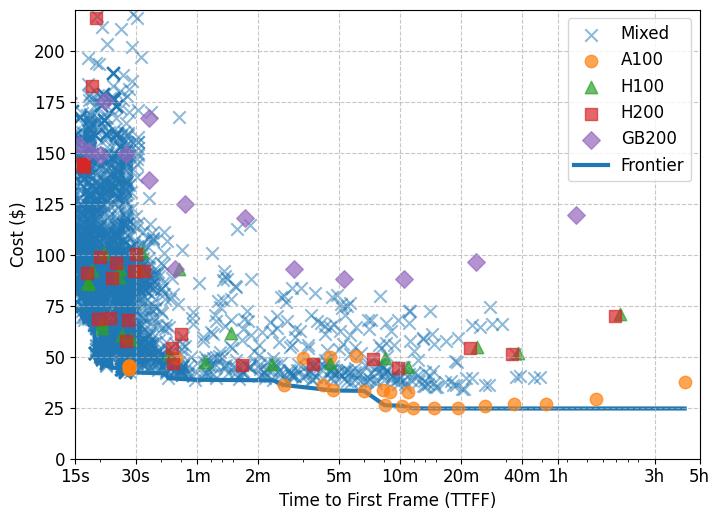

In [ ]:
plot_ttff_vs_cost(
    ttffs=provisioning_streamwise.ttffs,
    costs=provisioning_streamwise.costs,
    provisions=provisioning_streamwise.actual_provision,
    ymax=220,
    xmin=10,
    xmax=5 * 60 * 60,
)

### Quality

In [14]:
latency_quality: dict[QualityLevel, LatencyData] = {}
provisioning_streamwise_quality: dict[QualityLevel, ProvisioningResult] = {}
for quality in [QualityLevel.HIGH, QualityLevel.MEDIUM, QualityLevel.LOW]:
    policy = replace(STREAMWISE_POLICY)
    policy.name = f"{STREAMWISE_POLICY.name} {quality.value}"
    latency_quality[quality] = load_adaptive_quality_data(
        data_dir=data_dir,
        level=quality,
    )
    provisioning_streamwise_quality[quality] = get_provisioning_results(
        workflow=workflow_config,
        latency_data=latency_quality[quality],
        policy=policy,
        verbose=False,
    )

streamwise high policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise medium policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise low policy:   0%|          | 0/4816 [00:00<?, ?it/s]

#### Adaptive quality

In [15]:
provisioning_result_adaptive = get_provisioning_adaptive_results(
    workflow_config=workflow_config,
    provisioning_qualities=provisioning_streamwise_quality,
)

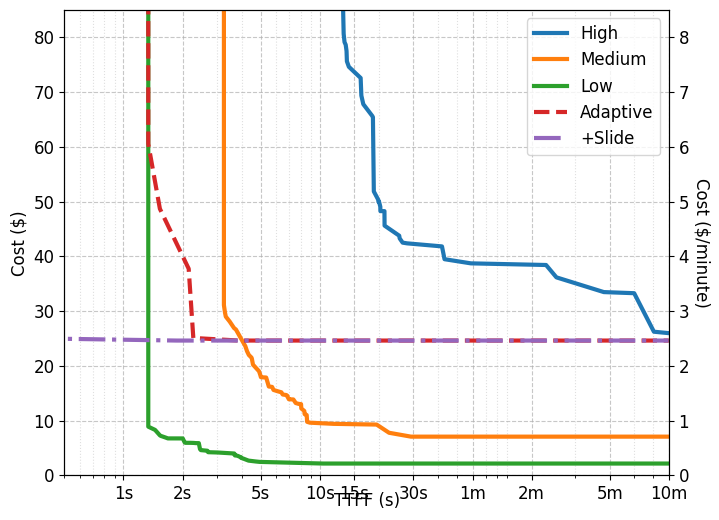

In [16]:
plot_adaptive_quality(
    slide_seconds=2.0,
    xmin=0.5,
    provisioning_result_adaptive=provisioning_result_adaptive,
    provisioning_qualities=provisioning_streamwise_quality,
)

### Multi-Requests
#### High quality

In [17]:
from sim_types import GPUType
from sim_types import Model

from multirequests import TIME_PER_REQ
from multirequests import INIT_REPLICAS
from multirequests import QPM_LIST

from multirequests import get_replicas
from multirequests import get_costs
from multirequests import get_total_costs

from constants import GPU_SPOT_COST

from plot_utils import plot_cost_vs_qpm

In [18]:
video_minutes = 10
video_seconds = video_minutes * 60

In [19]:
replicas_multirequests = get_replicas(
    video_seconds=video_seconds,
    time_per_req=TIME_PER_REQ,
    init_replicas=INIT_REPLICAS,
    qpms=QPM_LIST,
)

In [20]:
print("Required replicas for each component at varying QPM")
df_replicas = pd.concat([
    pd.DataFrame(replicas_multirequests[GPUType.A100]).add_suffix(" A100"),
    pd.DataFrame(replicas_multirequests[GPUType.H100]).add_suffix(" H100"),
], axis=1)
df_replicas["QPM"] = QPM_LIST
df_replicas.set_index("QPM")

Required replicas for each component at varying QPM


,Model.OTHERS A100,Model.GEMMA A100,Model.FLUX A100,Model.HF A100,Model.HF_VAE A100,Model.FT A100,Model.UPSCALER A100,Model.FT H100
QPM,,,,,,,,
0.1,1,1,1,12,3,172,21,78
1.0,1,1,1,25,6,376,45,78
2.0,1,2,1,50,12,751,89,155
5.0,3,3,1,124,29,1876,222,387
10.0,5,6,2,247,58,3751,444,774
20.0,9,11,4,493,115,7501,888,1547
30.0,13,16,5,739,172,11251,1332,2320
50.0,22,27,9,1231,286,18751,2220,3866
100.0,43,53,17,2462,572,37502,4440,7731


In [21]:
# Calculate the cost for each component based on the required replicas and the per hour price
costs_multirequests = get_costs(
    replicas=replicas_multirequests,
    gpu_costs=GPU_SPOT_COST,
)
total_costs = get_total_costs(costs_multirequests)

In [22]:
print("Per-hour cost for each component based on required replicas")
df_costs_multirequests = pd.concat([
    pd.DataFrame(costs_multirequests[GPUType.A100]).add_suffix(" A100"),
    pd.DataFrame(costs_multirequests[GPUType.H100]).add_suffix(" H100"),
], axis=1)
df_costs_multirequests["QPM"] = QPM_LIST
df_costs_multirequests = df_costs_multirequests.set_index("QPM")
df_costs_multirequests = df_costs_multirequests.rename(columns={
    "Model.OTHERS A100": "Kokoro ($)",
    "Model.GEMMA A100": "Gemma ($)",
    "Model.FLUX A100": "Flux ($)",
    "Model.HF A100": "HunyuanFramepackF1 ($)",
    "Model.HF_VAE A100": "VAE ($)",
    "Model.FT A100": "FantasyTalking A100 ($)",
    "Model.UPSCALER A100": "Upscaler ($)",
    "Model.FT H100": "FantasyTalking H100 ($)",
})
df_costs_multirequests

Per-hour cost for each component based on required replicas


,Kokoro ($),Gemma ($),Flux ($),HunyuanFramepackF1 ($),VAE ($),FantasyTalking A100 ($),Upscaler ($),FantasyTalking H100 ($)
QPM,,,,,,,,
0.1,1.07,1.07,1.07,12.84,3.21,184.04,22.47,314.34
1.0,1.07,1.07,1.07,26.75,6.42,402.32,48.15,314.34
2.0,1.07,2.14,1.07,53.50,12.84,803.57,95.23,624.65
5.0,3.21,3.21,1.07,132.68,31.03,2007.32,237.54,1559.61
10.0,5.35,6.42,2.14,264.29,62.06,4013.57,475.08,3119.22
20.0,9.63,11.77,4.28,527.51,123.05,8026.07,950.16,6234.41
30.0,13.91,17.12,5.35,790.73,184.04,12038.57,1425.24,9349.60
50.0,23.54,28.89,9.63,1317.17,306.02,20063.57,2375.40,15579.98
100.0,46.01,56.71,18.19,2634.34,612.04,40127.14,4750.80,31155.93


In [23]:
init_cost: dict[GPUType, dict[Model, float]] = {}
for gpu_type in INIT_REPLICAS.keys():
    init_cost[gpu_type] = {}
    for model in INIT_REPLICAS[gpu_type].keys():
        init_cost[gpu_type][model] = INIT_REPLICAS[gpu_type][model] * GPU_SPOT_COST[gpu_type]

In [24]:
print("Initial Cost for each component based on initial replicas")
print(f"{'Component':<20} {'GPU Type':<10} {'Initial Replicas':<20} {'Cost ($)':<15}")
for gpu_type in INIT_REPLICAS.keys():
    for model in INIT_REPLICAS[gpu_type].keys():
        print(f"{model.name:<20} {gpu_type.name:<10} {INIT_REPLICAS[gpu_type][model]:<20} {init_cost[gpu_type][model]:8.2f}")

init_total_cost = sum(init_cost[GPUType.A100].values()) + sum(init_cost[GPUType.H100].values())
print(f"Initial total cost for all components: ${init_total_cost:.2f}")

Initial Cost for each component based on initial replicas
Component            GPU Type   Initial Replicas     Cost ($)       
OTHERS               A100       1                        1.07
GEMMA                A100       1                        1.07
FLUX                 A100       1                        1.07
HF                   A100       12                      12.84
VAE                  A100       3                        3.21
FT                   A100       172                    184.04
UPSCALER             A100       21                      22.47
FT                   H100       78                     314.34
Initial total cost for all components: $540.11


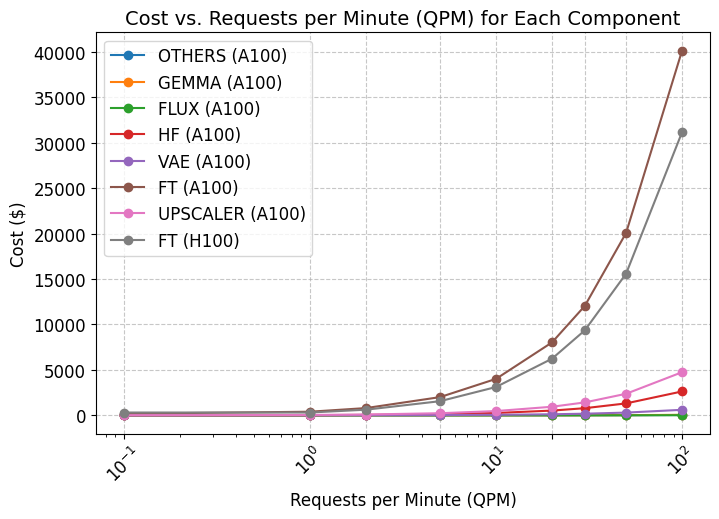

In [25]:
plot_cost_vs_qpm(
    costs=costs_multirequests,
    qpms=QPM_LIST,
)


#### Adaptive quality

In [26]:
import pandas as pd

from constants import GPU_SPOT_COST

from sim_types import GPUType
from sim_types import Model
from sim_types import QualityLevel

from multirequests import QPM_LIST
from multirequests import QUALITY_PORTIONS
from multirequests import INIT_REPLICAS_ADAPTIVE
from multirequests import TIME_PER_REQ_ADAPTIVE
from multirequests import get_costs
from multirequests import get_total_costs
from multirequests import get_replicas
from multirequests import aggregate_time_per_request_by_quality

from plot_utils import plot_cost_vs_qpm

In [27]:
# portion_low: 112, portion_medium: 305, portion_high: 13383
total_portions = sum(QUALITY_PORTIONS.values())

video_seconds = 10 * 60  # 10 minutes
video_seconds_low = video_seconds * QUALITY_PORTIONS[QualityLevel.LOW] / total_portions
video_seconds_medium = video_seconds * QUALITY_PORTIONS[QualityLevel.MEDIUM] / total_portions
video_seconds_high = video_seconds * QUALITY_PORTIONS[QualityLevel.HIGH] / total_portions

print(f"Video for low portion: {video_seconds_low:.2f} seconds")
print(f"Video for medium portion: {video_seconds_medium:.2f} seconds")
print(f"Video for high portion: {video_seconds_high:.2f} seconds")
print(f"Video duration: {video_seconds:.2f} seconds")

Video for low portion: 4.87 seconds
Video for medium portion: 13.26 seconds
Video for high portion: 581.87 seconds
Video duration: 600.00 seconds


In [28]:
time_req_adaptive_agg = aggregate_time_per_request_by_quality(
    time_per_req=TIME_PER_REQ_ADAPTIVE,
    quality_portions=QUALITY_PORTIONS
)

In [29]:
replicas_adaptive = get_replicas(
    video_seconds=video_seconds,
    time_per_req=time_req_adaptive_agg,
    init_replicas=INIT_REPLICAS_ADAPTIVE,
    qpms=QPM_LIST,
)

In [30]:
print("Required replicas for each component at varying QPM")
df_replicas_adaptive = pd.concat([
    pd.DataFrame(replicas_adaptive[GPUType.A100]).add_suffix(" A100"),
    pd.DataFrame(replicas_adaptive[GPUType.H100]).add_suffix(" H100"),
], axis=1)
df_replicas_adaptive["QPM"] = QPM_LIST
df_replicas_adaptive.set_index("QPM")

Required replicas for each component at varying QPM


,Model.OTHERS A100,Model.GEMMA A100,Model.FLUX A100,Model.HF A100,Model.HF_VAE A100,Model.UPSCALER A100,Model.HF_VAE H100,Model.FT H100,Model.UPSCALER H100
QPM,,,,,,,,,
0.1,1,8,16,25,10,5,1,96,38
1.0,1,8,16,25,10,5,1,205,38
2.0,1,8,16,25,17,6,2,410,43
5.0,3,8,16,56,43,14,5,1025,107
10.0,5,13,16,111,85,28,9,2050,213
20.0,9,26,16,221,170,56,17,4100,426
30.0,13,39,16,332,255,84,26,6150,638
50.0,22,65,16,552,425,140,43,10250,1063
100.0,43,130,26,1104,849,280,85,20500,2126


In [31]:
costs_adaptive = get_costs(
    replicas=replicas_adaptive,
    gpu_costs=GPU_SPOT_COST,
)
total_costs_adaptive = get_total_costs(costs_adaptive)

In [32]:
# output to CSV
df_multi_req_cost = pd.DataFrame({
    "QPM": QPM_LIST,
    "Kokoro ($)": costs_adaptive[GPUType.A100][Model.OTHERS],
    "Gemma ($)": costs_adaptive[GPUType.A100][Model.GEMMA],
    "Flux ($)": costs_adaptive[GPUType.A100][Model.FLUX],
    "HunyuanFramepackF1 ($)": costs_adaptive[GPUType.A100][Model.HF],
    "VAE ($)": [
        c0 + c1
        for c0, c1 in zip(
            costs_adaptive[GPUType.A100][Model.HF_VAE],
            costs_adaptive[GPUType.H100][Model.HF_VAE])
    ],
    "FantasyTalking ($)": costs_adaptive[GPUType.H100][Model.FT],
    "Upscaler ($)": [
        c0 + c1
        for c0, c1 in zip(
            costs_adaptive[GPUType.A100][Model.UPSCALER],
            costs_adaptive[GPUType.H100][Model.UPSCALER])
    ],
    "Total ($)": total_costs_adaptive
})

df_multi_req_cost.to_csv(results_dir + "multi_req_cost.csv", index=False)

In [33]:
print("Per-hour Cost for each component based on required replicas")
df_multi_req_cost.set_index("QPM")

Per-hour Cost for each component based on required replicas


,Kokoro ($),Gemma ($),Flux ($),HunyuanFramepackF1 ($),VAE ($),FantasyTalking ($),Upscaler ($),Total ($)
QPM,,,,,,,,
0.1,1.07,8.56,17.12,26.75,14.73,386.88,158.49,613.60
1.0,1.07,8.56,17.12,26.75,14.73,826.15,158.49,1052.87
2.0,1.07,8.56,17.12,26.75,26.25,1652.30,179.71,1911.76
5.0,3.21,8.56,17.12,59.92,66.16,4130.75,446.19,4731.91
10.0,5.35,13.91,17.12,118.77,127.22,8261.50,888.35,9432.22
20.0,9.63,27.82,17.12,236.47,250.41,16523.00,1776.70,18841.15
30.0,13.91,41.73,17.12,355.24,377.63,24784.50,2661.02,28251.15
50.0,23.54,69.55,17.12,590.64,628.04,41307.50,4433.69,47070.08
100.0,46.01,139.10,27.82,1181.28,1250.98,82615.00,8867.38,94127.57


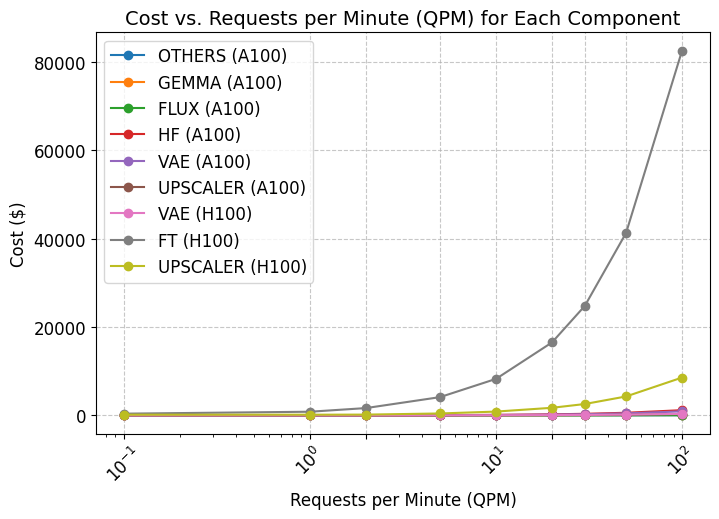

In [34]:
plot_cost_vs_qpm(
    costs=costs_adaptive,
    qpms=QPM_LIST
)

## Baselines

In [35]:
import pandas as pd

from dataclasses import replace

from policies import STREAMWISE_POLICY
from policies import BASELINE_POLICIES
from policies import STREAMWISE_POLICIES

from sim_types import Objective
from sim_types import GPUType

from provisioning import get_provisioning_results

from workflows import PODCAST_WORKFLOW

from data_loading import load_latency_data
from data_loading import load_power_data

from plot_utils import plot_policies_ttff_vs_cost

In [36]:
data_dir = "data/"

In [37]:
podcast_config = PODCAST_WORKFLOW

In [38]:
latency_data = load_latency_data(data_dir=data_dir)
power_data = load_power_data(data_dir=data_dir)

In [39]:
policies = BASELINE_POLICIES
policies["streamwise"] = STREAMWISE_POLICY

provisioning_baselines: dict[str, ProvisioningResult] = {}
for policy_name, policy in policies.items():
    provision_result = get_provisioning_results(
        workflow=podcast_config,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        verbose=False,
    )
    provisioning_baselines[policy_name] = provision_result

naive policy:   0%|          | 0/28 [00:00<?, ?it/s]

naive disag policy:   0%|          | 0/28 [00:00<?, ?it/s]

naive upscaler policy:   0%|          | 0/28 [00:00<?, ?it/s]

naive spot policy:   0%|          | 0/28 [00:00<?, ?it/s]

naive ttff*cost allocator policy:   0%|          | 0/28 [00:00<?, ?it/s]

naive hardware policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/4816 [00:00<?, ?it/s]

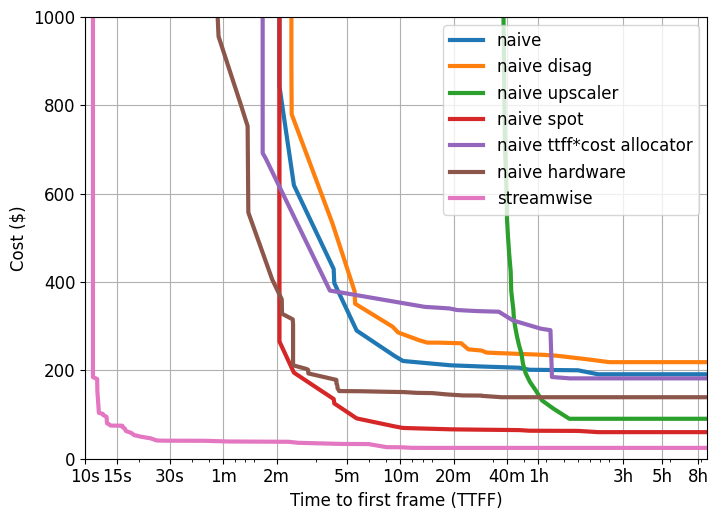

In [40]:
plot_policies_ttff_vs_cost(
    provisioning_baselines,
    points=False,
    front=True,
    xmin=10,
    xmax=9 * 60 * 60,
    ymax=1000,
)

## StreamWise Allocator

In [41]:
provisioning_streamwise_allocator: dict[str, ProvisioningResult] = {}
for objective in Objective:
    policy = replace(STREAMWISE_POLICY)
    policy.objective = objective
    policy.name = f"{STREAMWISE_POLICY.name} {objective.value}"
    provision_result = get_provisioning_results(
        podcast_config,
        latency_data=latency_data,
        policy=policy,
        verbose=False,
    )
    provisioning_streamwise_allocator[f"streamwise {objective.value}"] = provision_result

streamwise naive policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise fifo policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise time policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise ttff policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise cost policy:   0%|          | 0/4816 [00:00<?, ?it/s]

...

streamwise energy_cost policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise time_energy policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise random policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise none policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise ttff_then_time policy:   0%|          | 0/4816 [00:00<?, ?it/s]

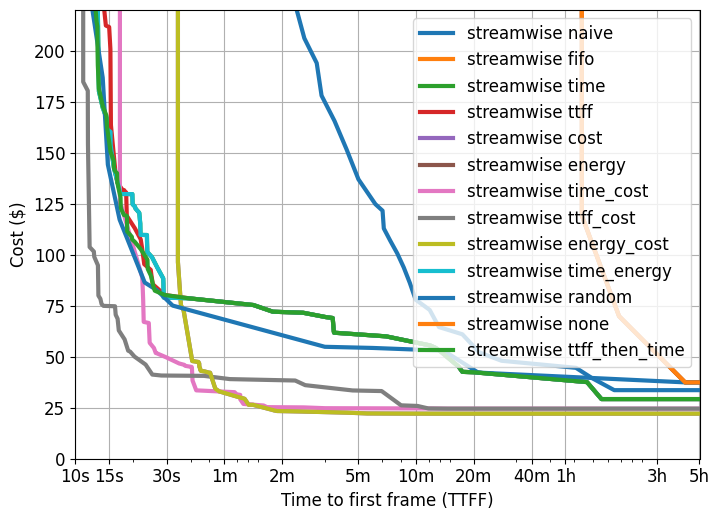

In [42]:
plot_policies_ttff_vs_cost(
    provisioning_streamwise_allocator,
    xmin=10,
    xmax=5 * 60 * 60,
    ymax=220,
    points=False,
    front=True,
)

## StreamWise vs Baselines

In [43]:
provisioning_streamwise_all = provisioning_baselines.copy()
provisioning_streamwise_all['streamwise'] = provisioning_streamwise
provisioning_streamwise_all['streamwise adaptive'] = provisioning_result_adaptive
for quality in [QualityLevel.HIGH, QualityLevel.MEDIUM, QualityLevel.LOW]:
    provisioning_streamwise_all[f"streamwise {quality.value}"] = provisioning_streamwise_quality[quality]

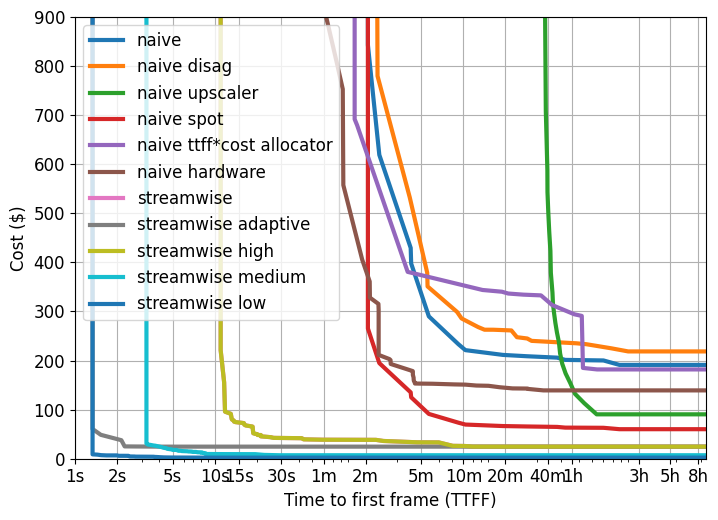

In [44]:
plot_policies_ttff_vs_cost(
    provisioning_streamwise_all,
    xmin=1,
    xmax=9 * 60 * 60,
    ymax=900,
    points=False,
    front=True,
)

## StreamWise ablation

In [ ]:
policies_streamwise = STREAMWISE_POLICIES

provisioning_streamwise_ablation: dict[str, ProvisioningResult] = {}
for policy_name, policy in policies_streamwise.items():
    provision_result = get_provisioning_results(
        workflow=podcast_config,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        verbose=False,
    )
    provisioning_streamwise_ablation[policy_name] = provision_result

streamwise policy:   0%|          | 0/4816 [00:00<?, ?it/s]

streamwise no disag policy:   0%|          | 0/4816 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcbea1a9ee0>><bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcbea1a9ee0>>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/inigog/.conda/envs/inigog/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
  File "/home/inigog/.conda/envs/inigog/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
        def _clean_thread_parent_frames(def _clean_thread_parent_frames(



KeyboardInterruptKeyboardInterrupt: : 

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcbea1a9ee0>>
Traceback (most recent call last):
  File "/home/inigog/.conda/envs/inigog/lib/python3.12/site-packages/ipykernel/ipkern

KeyboardInterrupt: 

  File "/home/inigog/.conda/envs/inigog/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcbea1a9ee0>>
Traceback (most recent call last):
  File "/home/inigog/.conda/envs/inigog/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
        def _clean_thread_parent_frames(
Exception ignored in: 
KeyboardInterrupt: 


def _clean_thread_parent_frames(Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcbea1a9ee0>><bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcbea1a9ee0>>
Traceback (most recent call last):
  File "/home/inigog/.conda/envs/inigog/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames

Exception ignored in:     Traceback (most recent call last):
def _clean_thread_parent_frames(<bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcbea1a9ee0>>


KeyboardInterrupt: 
Exception ignored in: Traceback (most recent call last):

<bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fcbea1a9ee0>>  File "/home/inigog/.conda/envs/inigog/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_pare

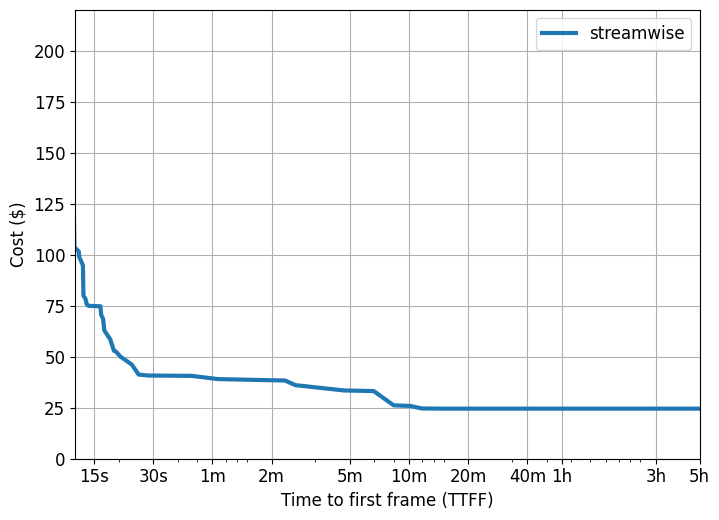

In [46]:
plot_policies_ttff_vs_cost(
    provisioning_streamwise_ablation,
    xmin=12,
    xmax=5 * 60 * 60,
    ymax=220,
    points=False,
    front=True,
)

# Save results

In [ ]:
for provisionings in [
    provisioning_baselines,
    provisioning_streamwise_ablation,
    provisioning_streamwise_allocator,
    provisioning_streamwise_all,
]:
    for policy_name, result in provisionings.items():
        result.save(policy_name, results_dir)

Data for 'naive' saved to results/provisioning_naive.csv with 28 rows.
Data for 'naive disag' saved to results/provisioning_naive_disag.csv with 28 rows.
Data for 'naive upscaler' saved to results/provisioning_naive_upscaler.csv with 28 rows.
Data for 'naive spot' saved to results/provisioning_naive_spot.csv with 28 rows.
Data for 'naive ttff*cost allocator' saved to results/provisioning_naive_ttffxcost_allocator.csv with 28 rows.
Data for 'naive hardware' saved to results/provisioning_naive_hardware.csv with 4816 rows.
Data for 'streamwise' saved to results/provisioning_streamwise.csv with 4816 rows.
Data for 'streamwise' saved to results/provisioning_streamwise.csv with 4816 rows.
Data for 'streamwise naive' saved to results/provisioning_streamwise_naive.csv with 4816 rows.
Data for 'streamwise fifo' saved to results/provisioning_streamwise_fifo.csv with 4816 rows.
Data for 'streamwise time' saved to results/provisioning_streamwise_time.csv with 4816 rows.
Data for 'streamwise ttff' 